In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pickle

In [ ]:
df = pd.read_csv(r"D:\Projects\Money Vest\Silver Price Prediction\Silver.csv")

In [3]:
df.head()

,Date,Price,Open,High,Low
0,10/29/2023,22.953,23.180,23.747,22.907
1,10/22/2023,22.887,23.505,23.505,22.565
2,10/15/2023,23.504,22.910,23.880,22.535
3,10/8/2023,22.895,21.940,22.990,21.705
4,10/1/2023,21.723,22.410,22.410,20.850


In [4]:
df.describe()

,Price,Open,High,Low
count,625.000000,625.000000,625.000000,625.000000
mean,20.495224,20.540670,21.091086,19.919312
std,5.069221,5.101513,5.267096,4.879329
min,12.385000,12.615000,14.205000,11.640000
25%,16.466000,16.480000,16.890000,16.150000
50%,19.120000,19.155000,19.750000,18.665000
75%,23.900000,24.025000,24.545000,23.030000
max,35.338000,35.430000,37.580000,34.210000


In [5]:
df.isnull().sum()

Date     0
Price    0
Open     0
High     0
Low      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    625 non-null    object 
 1   Price   625 non-null    float64
 2   Open    625 non-null    float64
 3   High    625 non-null    float64
 4   Low     625 non-null    float64
dtypes: float64(4), object(1)
memory usage: 24.5+ KB


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    625 non-null    datetime64[ns]
 1   Price   625 non-null    float64       
 2   Open    625 non-null    float64       
 3   High    625 non-null    float64       
 4   Low     625 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 24.5 KB


# Feature Scaling

In [9]:
df.set_index('Date', inplace = True)

In [10]:
df.columns

Index(['Price', 'Open', 'High', 'Low'], dtype='object')

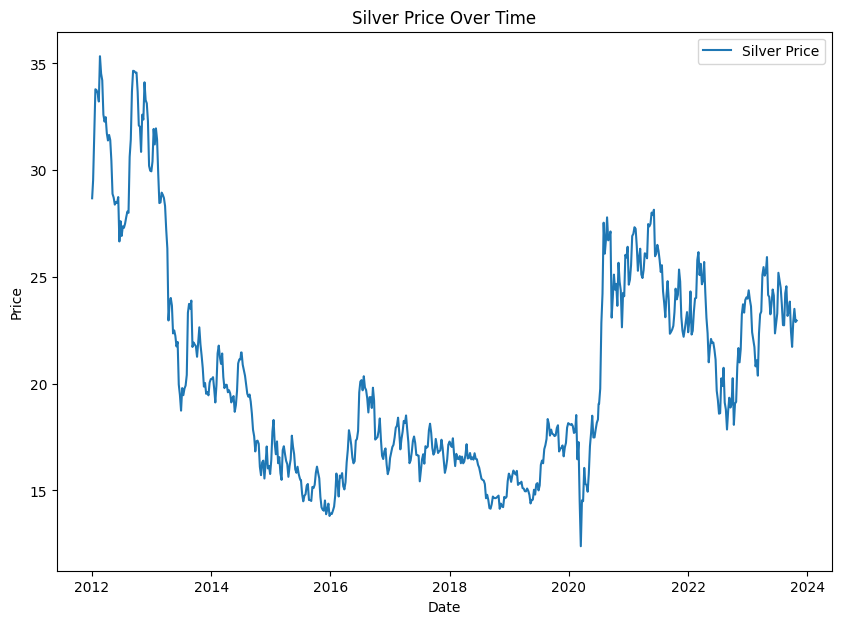

In [11]:
plt.figure(figsize = (10, 7))
plt.plot(df['Price'], label = 'Silver Price')
plt.title("Silver Price Over Time")
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


Since we are predicting future prices using the previous day's data. our target column will contain the prices of next day

In [12]:
df['Target'] = df['Price'].shift(-1) # Create a target column for next day's price

In [13]:
df.head()

,Price,Open,High,Low,Target
Date,,,,,
2023-10-29,22.953,23.180,23.747,22.907,22.887
2023-10-22,22.887,23.505,23.505,22.565,23.504
2023-10-15,23.504,22.910,23.880,22.535,22.895
2023-10-08,22.895,21.940,22.990,21.705,21.723
2023-10-01,21.723,22.410,22.410,20.850,22.450


In [14]:
df = df.dropna()

In [15]:
df = df.sort_values(by = 'Date')

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Price', 'Open', 'High', 'Low']])
pickle.dump(scaler, open('silver_scaler.pkl', 'wb'))
y = df['Target']

# Model Training

Best ML models for prediction especially in a times series format are : Linear Regression(Simple interpretable), Random Forest Regressor(Handles non-linearities), XGBoost/ LightGBM(handles noise, fast)

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

# 1.Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
model_linear = LinearRegression()
model_linear.fit(x_train, y_train)
y_linear_pred = model_linear.predict(x_test)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse_linear = mean_squared_error(y_test, y_linear_pred)
r2_linear = r2_score(y_test, y_linear_pred)
mae_linear = mean_absolute_error(y_test, y_linear_pred)
print(f"Linear Regression - MSE: {mse_linear}, R2: {r2_linear}, MAE: {mae_linear}")

Linear Regression - MSE: 0.019133379373703185, R2: 0.9991898966848325, MAE: 0.08393833860409299


Linear Regression 
- MSE: 0.019133379373703185
- R2: 0.9991898966848325
- MAE: 0.08393833860409299

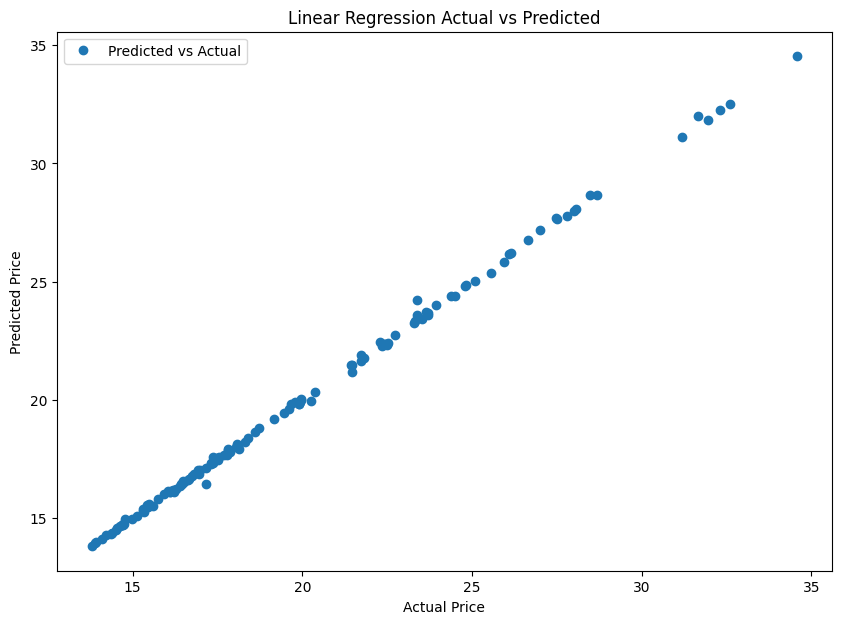

In [20]:
plt.figure(figsize=(10, 7))
plt.plot(y_test, y_linear_pred, 'o', label='Predicted vs Actual')
plt.title('Linear Regression Actual vs Predicted')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

# 2.Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor()
model_rf.fit(x_train, y_train)
y_rf_pred  = model_rf.predict(x_test)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse_rf = mean_squared_error(y_test, y_rf_pred)
r2_rf = r2_score(y_test, y_rf_pred)
mae_rf = mean_absolute_error(y_test, y_rf_pred)
print(f"Random Forest Regressor - MSE: {mse_rf}, R2: {r2_rf}, MAE: {mae_rf}")

Random Forest Regressor - MSE: 0.029760418246200154, R2: 0.9987399500626034, MAE: 0.11378777333333519


Random Forest Regressor 
- MSE: 0.03220065903191107
- R2: 0.998636630773747
- MAE: 0.11598013333333491

# 3.XGBoost

In [23]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 42)
model_xgb.fit(x_train, y_train)
y_xgb_pred = model_xgb.predict(x_test)

In [24]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse_xgb = mean_squared_error(y_test, y_xgb_pred)
r2_xgb = r2_score(y_test, y_xgb_pred)
mae_xgb = mean_absolute_error(y_test, y_xgb_pred)
print(f"XGBoost Regressor - MSE: {mse_xgb}, R2: {r2_xgb}, MAE: {mae_xgb}")

XGBoost Regressor - MSE: 0.03329485294981032, R2: 0.9985903028301563, MAE: 0.1199051714477537


XGBoost Regressor 
- MSE: 0.03329485294981032
- R2: 0.9985903028301563
- MAE: 0.1199051714477537

In [28]:
import pickle

# Save the trained model
with open('silver_model.pkl', 'wb') as f:
    pickle.dump(model_xgb, f)